# Libraries


In [2]:
import numpy as np 
import pandas as pd

In [3]:
dataset = pd.read_csv('Crop_recommendation.csv')
dataset.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
        dataset.shape

(2200, 8)

## Exploratory Data Analysis (EDA)
Let's visualize the distribution of our chosen features and how they compare across different crops using `matplotlib.pyplot` and `seaborn`.

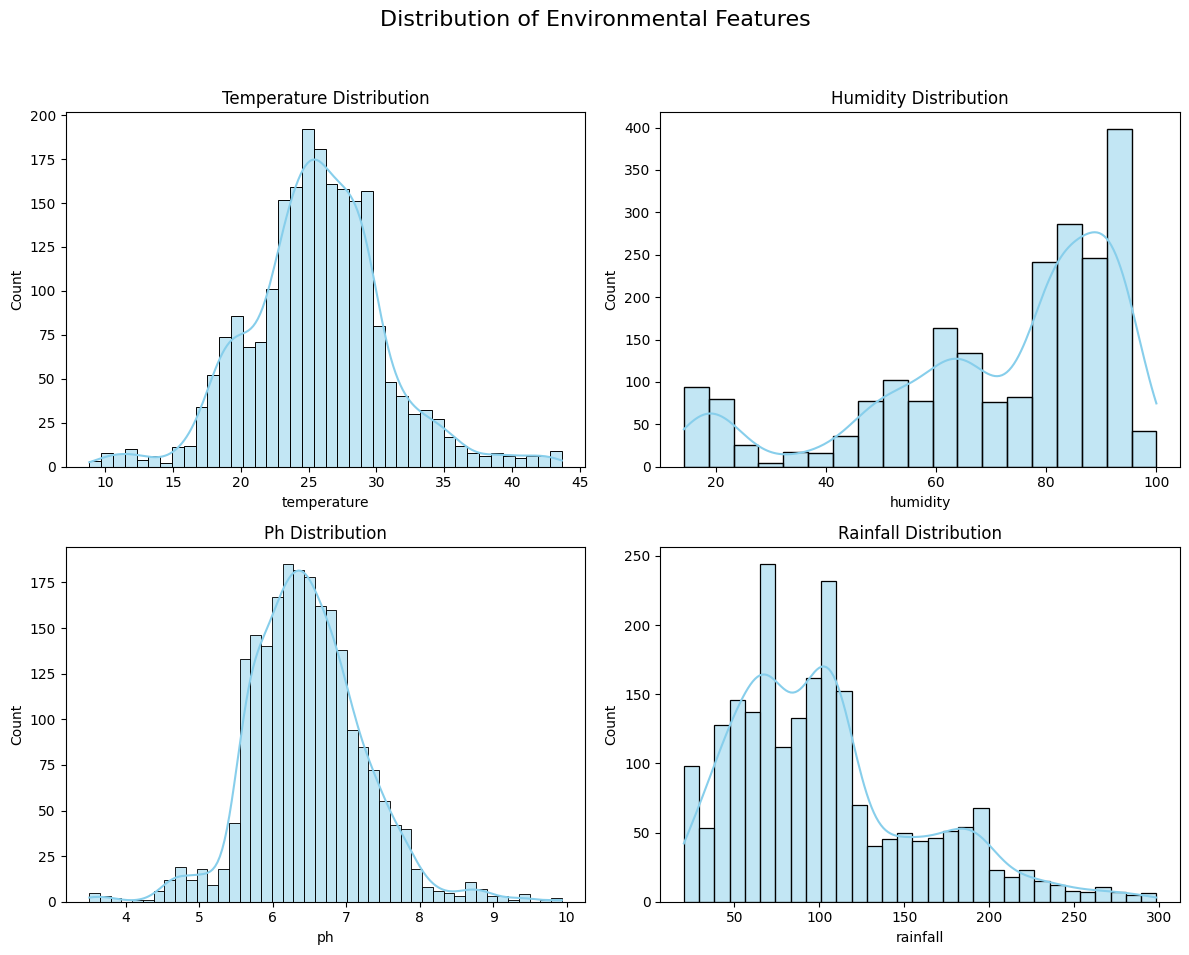

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up grid for subplots
features = ['temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Environmental Features', fontsize=16)

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.histplot(dataset[feature], kde=True, ax=axes[row, col], color='skyblue')
    axes[row, col].set_title(f'{feature.capitalize()} Distribution')
    axes[row, col].set_xlabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

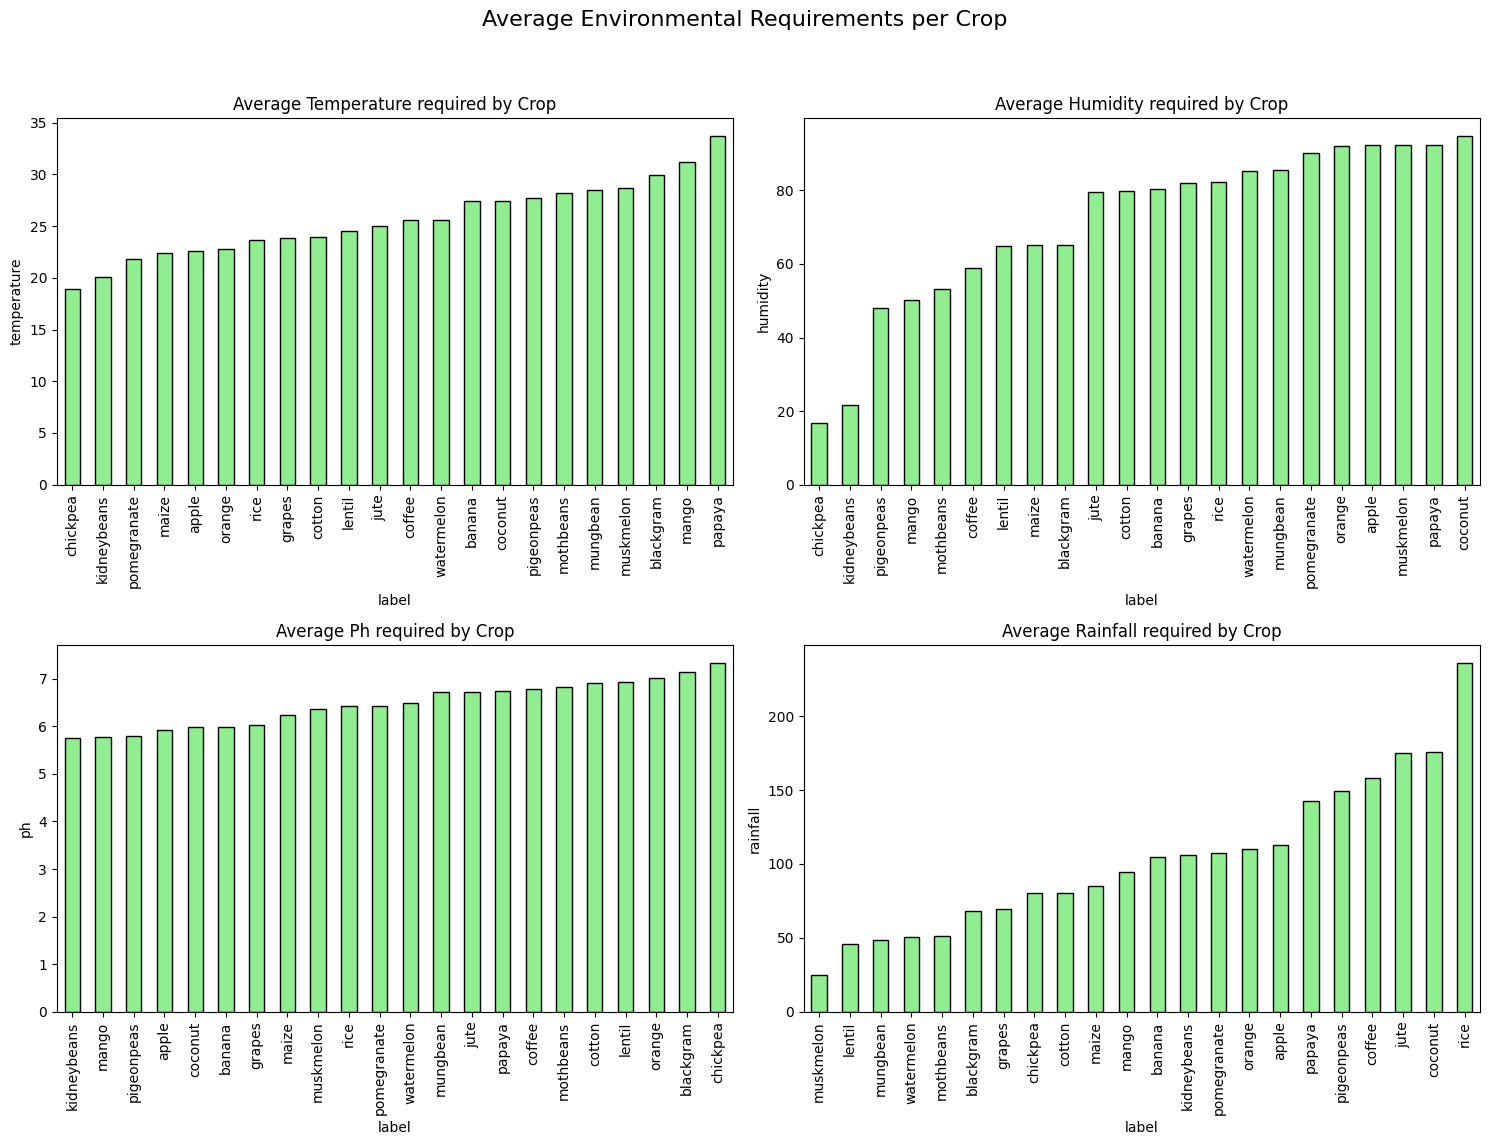

In [12]:
# Average features per crop to see which environment suits which crop best
avg_features = dataset.groupby('label')[features].mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Average Environmental Requirements per Crop', fontsize=16)

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    avg_features[feature].sort_values().plot(kind='bar', ax=axes[row, col], color='lightgreen', edgecolor='black')
    axes[row, col].set_title(f'Average {feature.capitalize()} required by Crop')
    axes[row, col].set_ylabel(feature)
    axes[row, col].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Feature Selection
We will use temperature, humidity, ph, and rainfall as features. We explicitly exclude N, P, and K.

In [8]:
X = dataset[['temperature', 'humidity', 'ph', 'rainfall']]
y = dataset['label']
X.head()

,temperature,humidity,ph,rainfall
0,20.879744,82.002744,6.502985,202.935536
1,21.770462,80.319644,7.038096,226.655537
2,23.004459,82.320763,7.840207,263.964248
3,26.491096,80.158363,6.980401,242.864034
4,20.130175,81.604873,7.628473,262.717340


## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1760, 4)
Testing data shape: (440, 4)


## Model Building and Evaluation
We will use a Random Forest Classifier which generally performs well on this type of tabular data.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 96.59%

Classification Report:
              precision    recall  f1-score   support

       apple       0.96      0.96      0.96        23
      banana       1.00      1.00      1.00        21
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       0.91      1.00      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.83      0.91        24
    mungbean       1.00      0.95      0.97        19
   muskmelon       1.00      1.00      1.00        17
      orange       0.81      0.93 

## Hyperparameter Tuning
We will use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model to ensure it is healthy and highly accurate.

In [15]:
from sklearn.model_selection import GridSearchCV

# Define a grid of hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize Grid Search, applying 5-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           verbose=1,
                           scoring='accuracy')

# Fit Grid Search to the training data
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy: 96.19%


In [16]:
# Retrieve the best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model validation
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy on Test Data: {tuned_accuracy * 100:.2f}%")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy on Test Data: 96.36%

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       apple       0.96      0.96      0.96        23
      banana       1.00      1.00      1.00        21
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       0.91      1.00      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.83      0.91        24
    mungbean       1.00      0.95      0.97        19
   muskmelon       1.00      1.00      1.00        17
 

## Interactive Crop Prediction
Run the cell below to input your own environmental data and get a real-time crop recommendation using our tuned model!

In [17]:
def make_prediction():
    print("\n--- Crop Recommendation System ---")
    print("Please enter the following environmental details:")
    
    try:
        temp = float(input("Temperature (in Celsius, e.g., 25.5): "))
        hum = float(input("Humidity (in %, e.g., 71.2): "))
        ph = float(input("pH value of the soil (e.g., 6.5): "))
        rain = float(input("Rainfall (in mm, e.g., 100.0): "))
        
        # Format input for the model
        input_data = pd.DataFrame(
            [[temp, hum, ph, rain]], 
            columns=['temperature', 'humidity', 'ph', 'rainfall']
        )
        
        # Make prediction
        prediction = best_model.predict(input_data)
        print("\n=========================================")
        print(f"  => Recommended Crop: {prediction[0].upper()} <=")
        print("=========================================")
        
    except ValueError:
        print("\n[Error] Invalid input detected. Please enter numerical values only.")

# Simply run the function to see the interactive prompts below:
make_prediction()


--- Crop Recommendation System ---
Please enter the following environmental details:

  => Recommended Crop: JUTE <=


## Save the Model
Save the trained `best_model` locally for FastAPI backend.

In [ ]:
import joblib
joblib.dump(best_model, 'crop_model.pkl')
print("Model saved as crop_model.pkl")

## Save the Model
Save the trained `best_model` locally for FastAPI backend.

In [ ]:
import joblib
joblib.dump(best_model, 'crop_model.pkl')
print("Model saved as crop_model.pkl")